In [1]:
import os
import sys
import numpy as np
from pathlib import Path

from torchvision import transforms
from PIL import Image

import torch
from compressai.zoo import cheng2020_anchor
from torchmetrics.image import PeakSignalNoiseRatio, StructuralSimilarityIndexMeasure


import h5py

import matplotlib.pyplot as plt

In [2]:
# Si tenemos disponible GPU, lo usamos
# Chequeamos si tenemos disponible GPU (CUDA)
if torch.cuda.is_available():
    device = "cuda"
# Chequeamos si tenemos disponible aceleración por hardware en un chip de Apple (MPS)
elif torch.backends.mps.is_available():
    device = "mps"
# Por defecto usamos CPU
else:
    device = "cpu"

In [3]:
# Me aseguro de que el directorio raíz del proyecto esté en el sys.path
project_root = Path(os.path.abspath("")).parent

# Añado el directorio raíz al sys.path si no está ya presente
if project_root not in sys.path:
    sys.path.append(str(project_root))

In [4]:
# Importo las funciones de configuración
from src.config import interim_data_dir, models_dir, raw_data_dir, load_config

from src.utils.datasets import CustomDataset

#from src.models.convolutional_autoencoder_model.model import ConvolutionalAutoencoder
#from src.models.compressai_chang2020_model.train_model import train_model
from src.models.compressai_chang2020_model.image_processing import pad_image_to_multiple
from src.models.compressai_chang2020_model.inference import decompress_image
from src.models.compressai_chang2020_model.compression_utils import load_compressed_data_from_h5, load_compressed_data_from_h5_2
from src.utils.metrics import compute_compression_ratio, compute_compression_ratio_from_h5_data


Current working directory: /home/jorge/development/ImageReconstructionDL/notebooks
Loading configuration from /home/jorge/development/ImageReconstructionDL/src/config.yaml


In [5]:
# Verifico que el dispositivo que se está utilizando
print(f"Usando dispositivo: {device}")

Usando dispositivo: cuda


In [6]:
nombre_modelo = "compressai_cheng2020_anchor_2_2_BIS.pth"
models_path = models_dir() / "trained"
model_path = models_path / nombre_modelo
# convierto a string
model_path = str(model_path)

# Cargo el modelo
modelo = cheng2020_anchor(quality=1, pretrained=True)
modelo.load_state_dict(torch.load(model_path, map_location=device))
modelo.eval().to(device)

Cheng2020Anchor(
  (entropy_bottleneck): EntropyBottleneck(
    (likelihood_lower_bound): LowerBound()
  )
  (g_a): Sequential(
    (0): ResidualBlockWithStride(
      (conv1): Conv2d(3, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (leaky_relu): LeakyReLU(negative_slope=0.01, inplace=True)
      (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (gdn): GDN(
        (beta_reparam): NonNegativeParametrizer(
          (lower_bound): LowerBound()
        )
        (gamma_reparam): NonNegativeParametrizer(
          (lower_bound): LowerBound()
        )
      )
      (skip): Conv2d(3, 128, kernel_size=(1, 1), stride=(2, 2))
    )
    (1): ResidualBlock(
      (conv1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (leaky_relu): LeakyReLU(negative_slope=0.01, inplace=True)
      (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
    (2): ResidualBlockWithStride(
      (conv1): Conv2d(1

In [7]:
# Inicialización de métricas
psnr_metric = PeakSignalNoiseRatio().to(device)
ssim_metric = StructuralSimilarityIndexMeasure().to(device)

In [8]:
# Para comparar
# Cargo una imagen y la convierto a tensor de 4 dimensiones
imagen_path = raw_data_dir() / "press" / "data" / "00005-1062776717.png"
imagen = Image.open(imagen_path).convert("RGB")
imagen = pad_image_to_multiple(imagen)

# Transformo la imagen a tensor
x = transforms.ToTensor()(imagen).unsqueeze(0).to(device)

In [9]:
# Cargo los datos comprimidos desde el archivo HDF5
compressed_data = load_compressed_data_from_h5("./comprimido_cae.h5", device=device)

Tamaño de y_hat_bytes leídos: 2064384 bytes
Tamaño de z_hat_bytes leídos: 129024 bytes


In [10]:
# La función load_compressed_data_from_h5 devuelve solo y_hat y z_hat
y_hat, z_hat = compressed_data

In [11]:
# Descomprimo la imagen comprimida y obtengo la imagen reconstruida
x_hat = decompress_image(modelo, y_hat)


In [12]:
# Guardo la imagen reconstruida
rec_net = transforms.ToPILImage()(x_hat.squeeze().cpu())
#rec_net.save('image_recontruida.png')

In [13]:
# Convierte la imagen reconstruida (PIL Image) a un tensor
x_hat_tensor = transforms.ToTensor()(rec_net).unsqueeze(0).to(device)

In [14]:
# Calcula las métricas
psnr_value = psnr_metric(x_hat_tensor, x)
ssim_value = ssim_metric(x_hat_tensor, x)


In [ ]:
# Calcula el ratio de compresión utilizando los datos comprimidos
# Dado que faltan algunos datos (como los mínimos y máximos), debemos ajustar el 
# cálculo del ratio de compresión.
compressed_data_dict = {
    'y_hat': y_hat,
    'y_hat_min': None,  # Coloca valores adecuados si tienes esta información disponible
    'y_hat_max': None,
    'y_shape': y_hat.shape,
    'z_hat': z_hat,
    'z_hat_min': None,
    'z_hat_max': None,
    'z_shape': z_hat.shape,
}
compression_ratio = compute_compression_ratio_from_h5_data(x, compressed_data_dict)

In [16]:
print(f"PSNR: {psnr_value}")
print(f"SSIM: {ssim_value}")
print(f"Compression ratio: {compression_ratio}")

PSNR: 28.62670135498047
SSIM: 0.9050090312957764
Compression ratio: 4.517647058823529


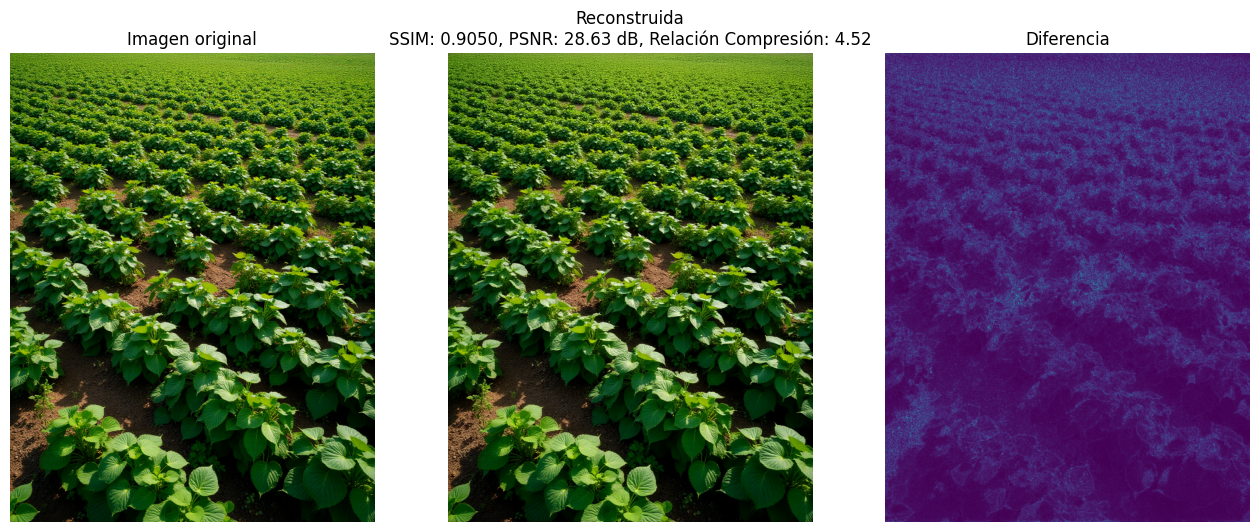

In [17]:
# Visualizar resultados
diff = torch.mean((x_hat - x).abs(), axis=1).squeeze().cpu()

fig, axes = plt.subplots(1, 3, figsize=(16, 12))
for ax in axes:
    ax.axis('off')

axes[0].imshow(imagen)
axes[0].title.set_text('Imagen original')

axes[1].imshow(rec_net)
axes[1].title.set_text('Imagen reconstruida')
axes[1].set_title(f"Reconstruida\nSSIM: {ssim_value:.4f}, PSNR: {psnr_value:.2f} dB, Relación Compresión: {compression_ratio:.2f}")
#axes[1].axis('off')

axes[2].imshow(diff, cmap='viridis')
axes[2].title.set_text('Diferencia')

plt.show()